In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, matthews_corrcoef,
    cohen_kappa_score, confusion_matrix
)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
class HybridDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]
class HybridRNNModel(nn.Module):
    def __init__(self, input_dim_per_phase, static_dim):
        super().__init__()

        # ===== RNN branch =====
        self.hidden_dim = 128
        self.num_layers = 1
        self.dropout_p = 0.3
        self.num_classes = 3

        self.rnn = nn.RNN(
            input_size=input_dim_per_phase,
            hidden_size=self.hidden_dim,
            num_layers=self.num_layers,
            batch_first=True,
            nonlinearity='tanh'
        )

        self.dropout = nn.Dropout(self.dropout_p)

        # ===== Static branch (MLP) =====
        self.mlp = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # ===== Fusion layer =====
        self.fc = nn.Linear(self.hidden_dim + 32, self.num_classes)

    def forward(self, x_seq, x_static):
        # ----- RNN branch -----
        out, h_n = self.rnn(x_seq)
        last_hidden = h_n[-1]
        last_hidden = self.dropout(last_hidden)

        # ----- MLP branch -----
        static_out = self.mlp(x_static)

        # ----- Combine -----
        combined = torch.cat([last_hidden, static_out], dim=1)

        return self.fc(combined)


In [3]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics


In [4]:
def evaluate_hybrid_model(
    model,
    loader,
    device,
    dataset_name,
    output_dir="results"
):
    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)

            outputs = model(xb_seq, xb_static)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Plot CM
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    # ===== Probability matrix =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred


# Hàm chuẩn bị dữ liệu và train

In [5]:
def prepare_and_train_hybrid(train_path, val_path=None):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    # ===== Tách label =====
    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    # Lấy tất cả feature time-series của cả 4 phase
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]
    
    phases_data = []
    
    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]
        print(f"Phase {p}: {len(cols_p)} features")
        phases_data.append(df_features[cols_p].values)
    
    X_seq = np.stack(phases_data, axis=1)
    
    print(f"Time-series shape: {X_seq.shape}")


    # ====== Tách feature static ======
    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].values

    print(f"Static feature shape: {X_static.shape}")

    # ====== Chuẩn hóa ======
    scaler_seq = StandardScaler()
    N, T, F = X_seq.shape

    X_seq = scaler_seq.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)

    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)

    # ===== Encode label =====
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    print(f"Classes: {le.classes_}")

    # ===== Dataset =====
    dataset = HybridDataset(X_seq, X_static, y_enc)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    # ===== Model =====
    model = HybridRNNModel(
        input_dim_per_phase=F,
        static_dim=X_static.shape[1]
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Train =====
    model.train()
    best_loss = float('inf')
    patience = 10
    wait = 0

    for epoch in range(50):
        epoch_loss = 0

        for xb_seq, xb_static, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            out = model(xb_seq, xb_static)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

        if epoch_loss < best_loss - 1e-4:
            best_loss = epoch_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print("Training done")

    return model, scaler_seq, scaler_static, le, phase_cols, static_cols


In [6]:
def run_and_report_hybrid(
    model,
    loader,
    device,
    dataset_name,
    version_name="HybridModel",
    phase="All"
):
    y_true, y_pred = evaluate_hybrid_model(
        model, loader, device, dataset_name
    )

    metrics = print_results(
        version_name=version_name,
        phase=phase,
        y_true=y_true,
        y_pred=y_pred
    )

    return metrics


# Chạy từng version

In [7]:
import time

def run_experiment(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train hybrid model =====
    start_train = time.perf_counter()

    model, scaler_seq, scaler_static, le, phase_cols, static_cols = \
        prepare_and_train_hybrid(train_path, val_path)

    time_build_model = time.perf_counter() - start_train

    results = []
    model.eval()

    with torch.no_grad():
        for phase, test_path in enumerate(test_files, 1):
            print(f"\n--- Test Phase {phase}: {test_path} ---")

            df_test = pd.read_csv(test_path)
            df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

            y_test = df_test['label_3'].values
            df_features = df_test.drop('label_3', axis=1)

            # ===== TÁCH TIME SERIES =====
            phases_data = []
    
            for p in ['1', '2', '3', '4']:
                cols_p = [c for c in phase_cols if f"_p{p}_" in c]
                phases_data.append(df_features[cols_p].values)
    
            X_seq = np.stack(phases_data, axis=1)

            # ===== Split static features =====
            X_static = df_features[static_cols].values

            # ===== Scaling =====
            N, T, F = X_seq.shape
            X_seq_scaled = scaler_seq.transform(
                X_seq.reshape(-1, F)
            ).reshape(N, T, F)

            X_static_scaled = scaler_static.transform(X_static)

            # ===== Convert to tensor =====
            X_seq_tensor = torch.FloatTensor(X_seq_scaled).to(device)
            X_static_tensor = torch.FloatTensor(X_static_scaled).to(device)

            # ===== Predict =====
            start_pred = time.perf_counter()

            outputs = model(X_seq_tensor, X_static_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            time_predict = time.perf_counter() - start_pred

            y_test_enc = le.transform(y_test)

            # ===== In metrics =====
            res = print_results(
                version_name=version_name,
                phase=phase,
                y_true=y_test_enc,
                y_pred=preds,
                time_build_model=time_build_model,
                time_predict=time_predict
            )

            # ===== Xuất confusion + probability =====
            run_and_report_hybrid(
                model=model,
                loader=DataLoader(
                    HybridDataset(X_seq_scaled, X_static_scaled, y_test_enc),
                    batch_size=256
                ),
                device=device,
                dataset_name=f"{version_name}_phase{phase}"
            )

            results.append(res)

    # ===== Tạo dataframe tổng hợp =====
    df = pd.DataFrame(results).round(10)

    # Đổi tên cột cho đúng (giữ nguyên logic cũ của bạn)
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]

    return df


## V1 (Median)

In [8]:
base_path = "/kaggle/input/lo-dataset/Median/Median"


#####
Version: V1 (Median)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0085
Epoch 2: loss = 0.0061
Epoch 3: loss = 0.0056
Epoch 4: loss = 0.0054
Epoch 5: loss = 0.0053
Epoch 6: loss = 0.0051
Epoch 7: loss = 0.0050
Epoch 8: loss = 0.0049
Epoch 9: loss = 0.0048
Epoch 10: loss = 0.0048
Epoch 11: loss = 0.0047
Epoch 12: loss = 0.0047
Epoch 13: loss = 0.0046
Epoch 14: loss = 0.0046
Epoch 15: loss = 0.0046
Epoch 16: loss = 0.0046
Epoch 17: loss = 0.0046
Epoch 18: loss = 0.0045
Epoch 19: loss = 0.0045
Epoch 20: loss = 0.0045
Epoch 21: loss = 0.0045
Epoch 22: loss = 0.0045
Epoch 23: loss = 0.0045
Epoch 24: loss = 0.0044
Epoch 25: loss = 0.0044
Epoch 26: loss = 0.0044
Epoch 27: loss = 0.0044
Epoch 28: loss = 0.0044
Epoch 29: loss = 0.00

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V1 (Median),1,1430.84617,0.054614,0.996034,0.356278,0.409558,0.993683,0.356278,0.996034,0.368296,0.994742,0.000000,0.111127,0.085212,0.000000,0.000000,0.000000,0.000000,0.232044,0.069421,0.106870,0.263401,0.996629,0.999413,0.998019,0.233058
1,V1 (Median),2,1430.84617,0.022420,0.996090,0.359594,0.420133,0.993800,0.359594,0.996090,0.373344,0.994814,0.000000,0.128879,0.098999,0.000000,0.000000,0.000000,0.000000,0.263736,0.079339,0.121982,0.281590,0.996663,0.999443,0.998051,0.252931
2,V1 (Median),3,1430.84617,0.020743,0.995771,0.417225,0.721111,0.994976,0.417225,0.995771,0.454587,0.995025,0.364376,0.212424,0.199224,0.913043,0.094170,0.170732,0.306871,0.253298,0.158678,0.195122,0.398100,0.996992,0.998826,0.997908,0.396006
3,V1 (Median),4,1430.84617,0.020796,0.998529,0.830360,0.890885,0.998420,0.830360,0.998529,0.855912,0.998438,0.855526,0.776886,0.773383,0.850877,0.869955,0.860310,0.932646,0.822757,0.621488,0.708098,0.788207,0.999021,0.999637,0.999329,0.851811


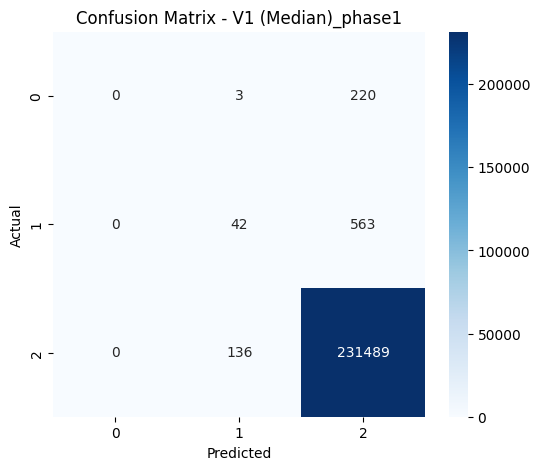

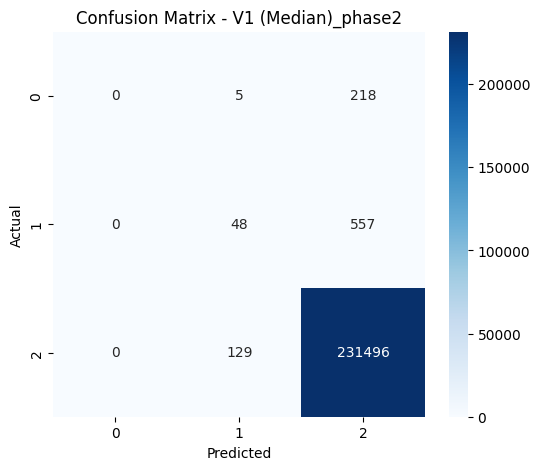

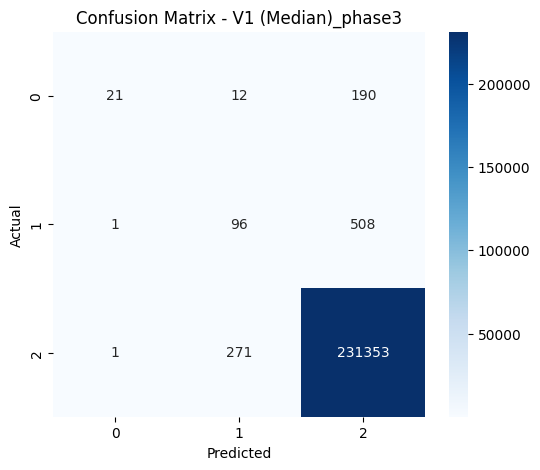

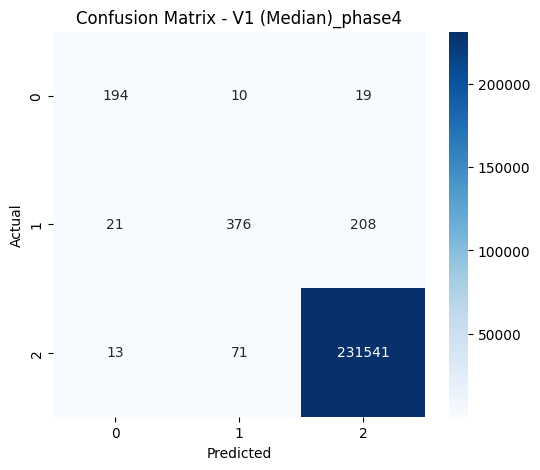

In [9]:
df_v1 = run_experiment(
    base_path=base_path,
    train_file="train_median.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V1 (Median)"
)
df_v1

In [10]:
df_v1.to_csv("results_v1.csv", index=False)

## V2 (Median CDSMOTE)


#####
Version: V2 (Median CDS)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0632
Epoch 2: loss = 0.0347
Epoch 3: loss = 0.0305
Epoch 4: loss = 0.0282
Epoch 5: loss = 0.0268
Epoch 6: loss = 0.0258
Epoch 7: loss = 0.0251
Epoch 8: loss = 0.0245
Epoch 9: loss = 0.0240
Epoch 10: loss = 0.0235
Epoch 11: loss = 0.0233
Epoch 12: loss = 0.0230
Epoch 13: loss = 0.0226
Epoch 14: loss = 0.0224
Epoch 15: loss = 0.0221
Epoch 16: loss = 0.0218
Epoch 17: loss = 0.0217
Epoch 18: loss = 0.0214
Epoch 19: loss = 0.0214
Epoch 20: loss = 0.0211
Epoch 21: loss = 0.0210
Epoch 22: loss = 0.0209
Epoch 23: loss = 0.0208
Epoch 24: loss = 0.0206
Epoch 25: loss = 0.0206
Epoch 26: loss = 0.0204
Epoch 27: loss = 0.0203
Epoch 28: loss = 0.0203
Epoch 29:

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V2 (Median CDS),1,4223.367928,0.019978,0.987998,0.452122,0.379725,0.994735,0.452122,0.987998,0.388512,0.991148,0.398699,0.196780,0.169020,0.057143,0.026906,0.036585,0.163995,0.084016,0.338843,0.134647,0.579290,0.998017,0.990618,0.994304,0.667129
1,V2 (Median CDS),2,4223.367928,0.019747,0.989357,0.478346,0.408419,0.994922,0.478346,0.989357,0.417064,0.991933,0.484204,0.224854,0.198630,0.123188,0.076233,0.094183,0.276032,0.103981,0.366942,0.162044,0.603253,0.998088,0.991862,0.994965,0.681752
2,V2 (Median CDS),3,4223.367928,0.019946,0.974150,0.725986,0.450049,0.996032,0.725986,0.974150,0.493804,0.984278,0.799086,0.247489,0.156825,0.283019,0.538117,0.370943,0.733084,0.067986,0.664463,0.123351,0.805400,0.999142,0.975378,0.987117,0.864203
3,V2 (Median CDS),4,4223.367928,0.020036,0.994481,0.936020,0.581034,0.997622,0.936020,0.994481,0.683839,0.995653,0.959015,0.598302,0.544163,0.362007,0.905830,0.517286,0.951021,0.381250,0.907438,0.536919,0.950763,0.999844,0.994793,0.997312,0.975470


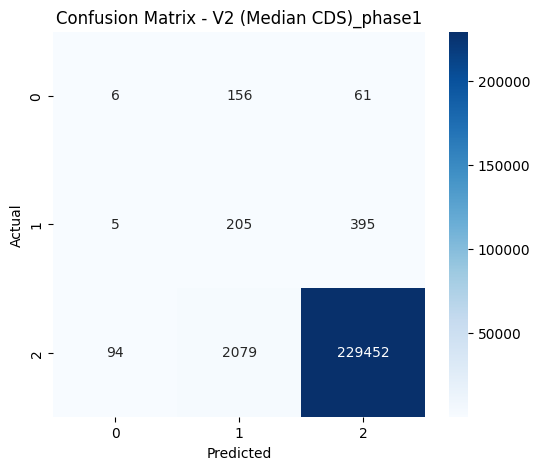

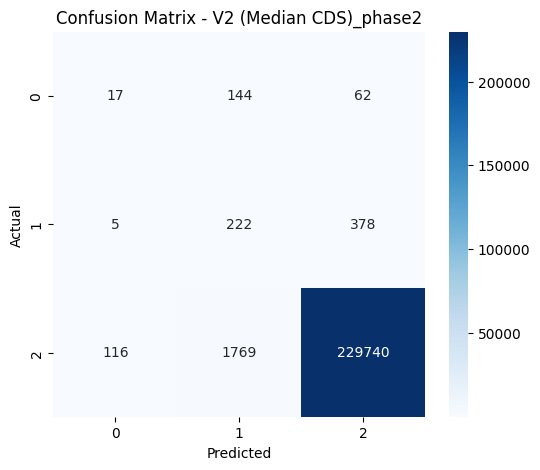

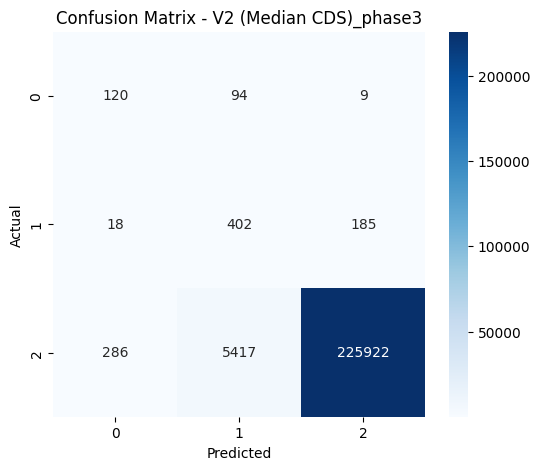

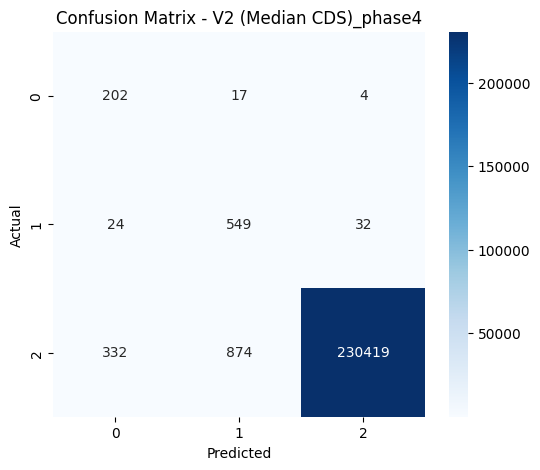

In [11]:
df_v2 = run_experiment(
    base_path=base_path,
    train_file="train_median_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V2 (Median CDS)"
)
df_v2

In [12]:
df_v2.to_csv("results_v2.csv", index=False)

## V3 (Median SASMOTE)


#####
Version: V3 (Median SAS)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0630
Epoch 2: loss = 0.0352
Epoch 3: loss = 0.0308
Epoch 4: loss = 0.0284
Epoch 5: loss = 0.0272
Epoch 6: loss = 0.0260
Epoch 7: loss = 0.0253
Epoch 8: loss = 0.0247
Epoch 9: loss = 0.0241
Epoch 10: loss = 0.0238
Epoch 11: loss = 0.0232
Epoch 12: loss = 0.0229
Epoch 13: loss = 0.0229
Epoch 14: loss = 0.0223
Epoch 15: loss = 0.0221
Epoch 16: loss = 0.0219
Epoch 17: loss = 0.0216
Epoch 18: loss = 0.0216
Epoch 19: loss = 0.0215
Epoch 20: loss = 0.0214
Epoch 21: loss = 0.0212
Epoch 22: loss = 0.0210
Epoch 23: loss = 0.0209
Epoch 24: loss = 0.0208
Epoch 25: loss = 0.0205
Epoch 26: loss = 0.0205
Epoch 27: loss = 0.0204
Epoch 28: loss = 0.0203
Epoch 29:

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V3 (Median SAS),1,4447.849978,0.020197,0.984943,0.584187,0.417834,0.994853,0.584187,0.984943,0.456805,0.989625,0.628250,0.194792,0.155071,0.194245,0.484305,0.277279,0.695249,0.061195,0.280992,0.100503,0.527097,0.998062,0.987264,0.992634,0.676655
1,V3 (Median SAS),2,4447.849978,0.020317,0.986673,0.591204,0.416156,0.994955,0.591204,0.986673,0.457197,0.990553,0.639874,0.216333,0.178420,0.173567,0.488789,0.256169,0.698353,0.076758,0.295868,0.121893,0.541406,0.998144,0.988956,0.993529,0.692925
2,V3 (Median SAS),3,4447.849978,0.020634,0.984543,0.707901,0.436831,0.995781,0.707901,0.984543,0.491714,0.989650,0.774346,0.285914,0.218519,0.209302,0.605381,0.311060,0.777208,0.102320,0.532231,0.171642,0.725084,0.998872,0.986090,0.992439,0.823911
3,V3 (Median SAS),4,4447.849978,0.020313,0.995160,0.918185,0.594917,0.997669,0.918185,0.995160,0.693997,0.996099,0.947160,0.614625,0.570574,0.368030,0.887892,0.520368,0.941590,0.416930,0.871074,0.563938,0.931829,0.999792,0.995588,0.997685,0.968438


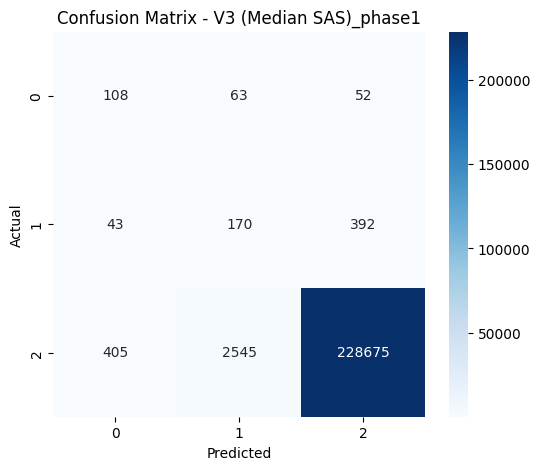

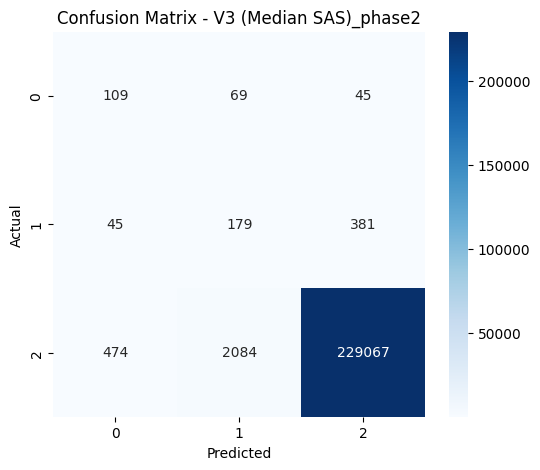

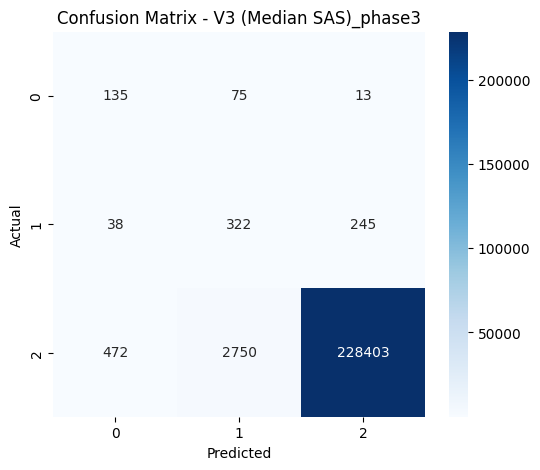

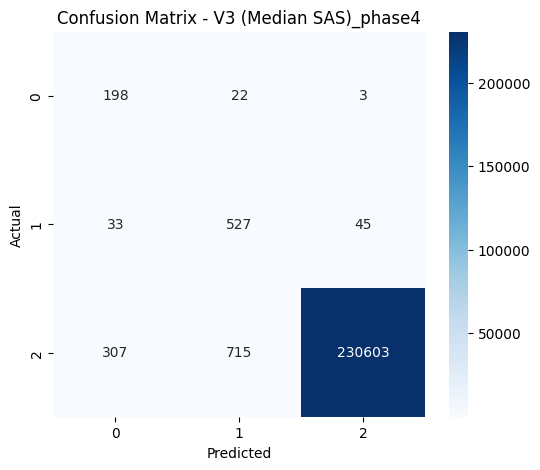

In [13]:
df_v3 = run_experiment(
    base_path=base_path,
    train_file="train_median_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V3 (Median SAS)"
)
df_v3

In [14]:
df_v3.to_csv("results_v3.csv", index=False)

## V4 (Median RadiusSMOTE)


#####
Version: V4 (Median Radius)
#####
Loading train: /kaggle/input/lo-dataset/Median/Median/train_median_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0525
Epoch 2: loss = 0.0256
Epoch 3: loss = 0.0218
Epoch 4: loss = 0.0200
Epoch 5: loss = 0.0188
Epoch 6: loss = 0.0181
Epoch 7: loss = 0.0174
Epoch 8: loss = 0.0168
Epoch 9: loss = 0.0164
Epoch 10: loss = 0.0161
Epoch 11: loss = 0.0159
Epoch 12: loss = 0.0156
Epoch 13: loss = 0.0155
Epoch 14: loss = 0.0152
Epoch 15: loss = 0.0150
Epoch 16: loss = 0.0151
Epoch 17: loss = 0.0151
Epoch 18: loss = 0.0149
Epoch 19: loss = 0.0149
Epoch 20: loss = 0.0148
Epoch 21: loss = 0.0147
Epoch 22: loss = 0.0145
Epoch 23: loss = 0.0145
Epoch 24: loss = 0.0144
Epoch 25: loss = 0.0143
Epoch 26: loss = 0.0142
Epoch 27: loss = 0.0142
Epoch 28: loss = 0.0140
Ep

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V4 (Median Radius),1,4713.71399,0.020479,0.989619,0.517630,0.442113,0.994884,0.517630,0.989619,0.449869,0.992020,0.536273,0.231221,0.205347,0.204082,0.134529,0.162162,0.366690,0.124337,0.426446,0.192537,0.650465,0.997919,0.991914,0.994908,0.646598
1,V4 (Median Radius),2,4713.71399,0.020164,0.987365,0.555116,0.445346,0.995398,0.555116,0.987365,0.454834,0.991016,0.597136,0.259486,0.214538,0.224359,0.156951,0.184697,0.396067,0.113235,0.519008,0.185909,0.716592,0.998445,0.989388,0.993896,0.750203
2,V4 (Median Radius),3,4713.71399,0.020256,0.988195,0.679303,0.484690,0.995981,0.679303,0.988195,0.529308,0.991671,0.751046,0.328294,0.270853,0.314935,0.434978,0.365348,0.659229,0.140265,0.613223,0.228308,0.779236,0.998871,0.989708,0.994268,0.824697
3,V4 (Median Radius),4,4713.71399,0.020559,0.996464,0.816766,0.642634,0.997356,0.816766,0.996464,0.708578,0.996828,0.860993,0.607868,0.596695,0.442786,0.798206,0.569600,0.892993,0.485890,0.654545,0.557746,0.808308,0.999226,0.997548,0.998386,0.884248


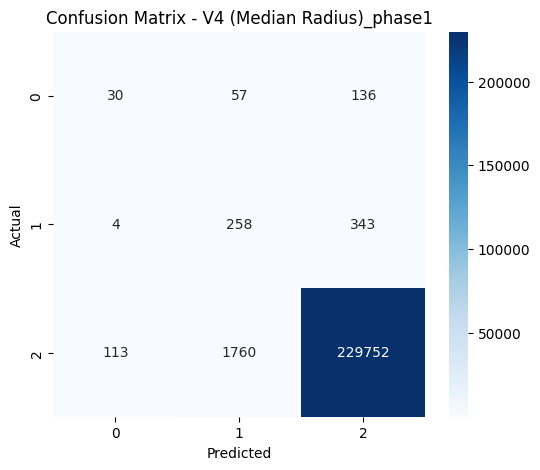

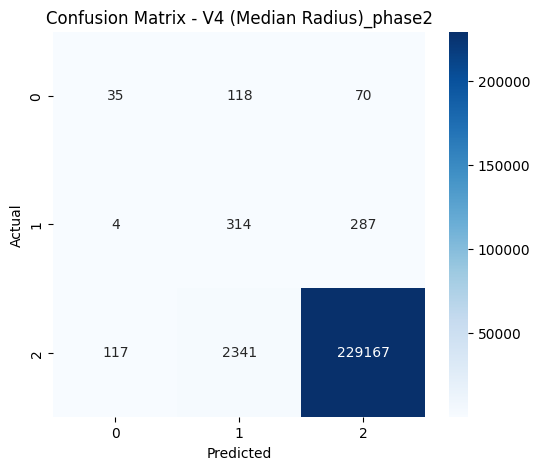

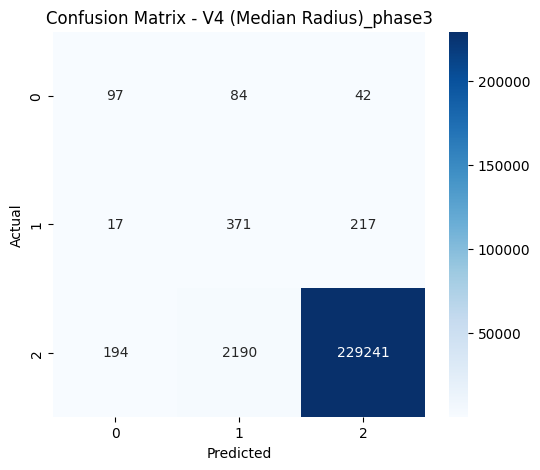

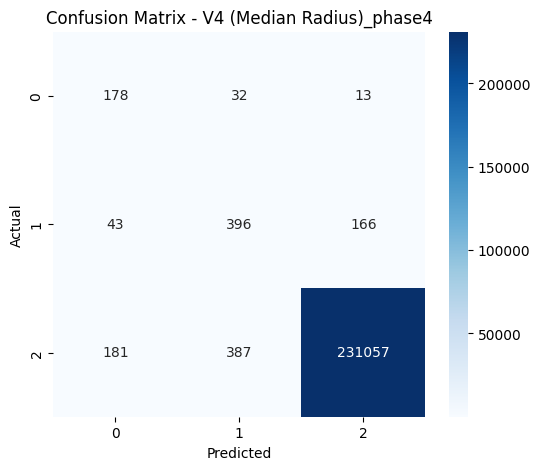

In [15]:
df_v4 = run_experiment(
    base_path=base_path,
    train_file="train_median_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V4 (Median Radius)"
)
df_v4

In [16]:
df_v4.to_csv("results_v4.csv", index=False)

## V5 (Mean)

In [17]:
base_path = "/kaggle/input/lo-dataset/Mean/Mean"


#####
Version: V5 (Mean)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0082
Epoch 2: loss = 0.0060
Epoch 3: loss = 0.0056
Epoch 4: loss = 0.0054
Epoch 5: loss = 0.0052
Epoch 6: loss = 0.0051
Epoch 7: loss = 0.0050
Epoch 8: loss = 0.0049
Epoch 9: loss = 0.0048
Epoch 10: loss = 0.0048
Epoch 11: loss = 0.0047
Epoch 12: loss = 0.0047
Epoch 13: loss = 0.0047
Epoch 14: loss = 0.0046
Epoch 15: loss = 0.0045
Epoch 16: loss = 0.0045
Epoch 17: loss = 0.0045
Epoch 18: loss = 0.0045
Epoch 19: loss = 0.0045
Epoch 20: loss = 0.0045
Epoch 21: loss = 0.0044
Epoch 22: loss = 0.0044
Epoch 23: loss = 0.0044
Epoch 24: loss = 0.0043
Epoch 25: loss = 0.0043
Epoch 26: loss = 0.0044
Epoch 27: loss = 0.0043
Epoch 28: loss = 0.0043
Epoch 29: loss = 0.0043
Epoch

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V5 (Mean),1,1175.460315,0.020390,0.996339,0.350885,0.454797,0.993982,0.350885,0.996339,0.363550,0.994851,0.000000,0.118420,0.069400,0.000000,0.000000,0.000000,0.000000,0.367816,0.052893,0.092486,0.229957,0.996574,0.999763,0.998166,0.196566
1,V5 (Mean),2,1175.460315,0.020525,0.996343,0.352535,0.459007,0.994028,0.352535,0.996343,0.366199,0.994874,0.000000,0.125989,0.075517,0.000000,0.000000,0.000000,0.000000,0.380435,0.057851,0.100430,0.240493,0.996587,0.999754,0.998168,0.205573
2,V5 (Mean),3,1175.460315,0.020495,0.996361,0.377676,0.749221,0.995054,0.377676,0.996361,0.406944,0.995130,0.267610,0.203015,0.153115,0.888889,0.035874,0.068966,0.189405,0.361963,0.097521,0.153646,0.312213,0.996810,0.999633,0.998219,0.324089
3,V5 (Mean),4,1175.460315,0.020453,0.998563,0.839642,0.890753,0.998462,0.839642,0.998563,0.861010,0.998480,0.863312,0.783434,0.780563,0.853448,0.887892,0.870330,0.942211,0.819742,0.631405,0.713352,0.794466,0.999068,0.999629,0.999348,0.859567


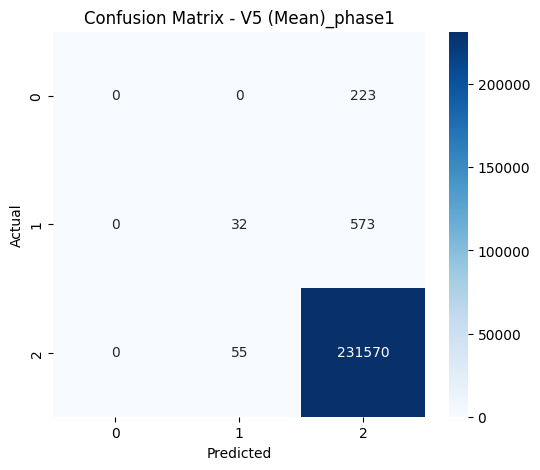

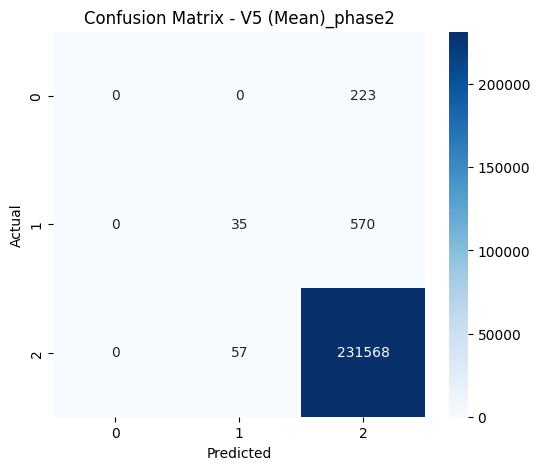

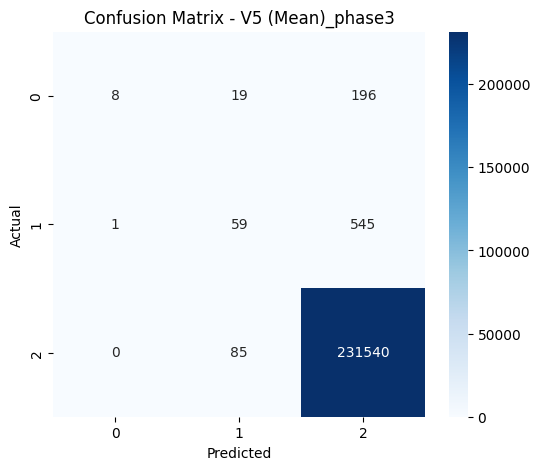

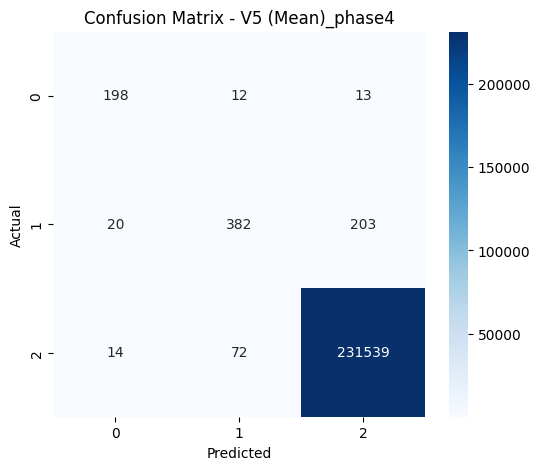

In [18]:
df_v5 = run_experiment(
    base_path=base_path,
    train_file="train_mean.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V5 (Mean)"
)
df_v5

In [19]:
df_v5.to_csv("results_v5.csv", index=False)

## V6 (Mean CDSMOTE)


#####
Version: V6 (Mean CDS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0646
Epoch 2: loss = 0.0375
Epoch 3: loss = 0.0326
Epoch 4: loss = 0.0301
Epoch 5: loss = 0.0283
Epoch 6: loss = 0.0272
Epoch 7: loss = 0.0263
Epoch 8: loss = 0.0256
Epoch 9: loss = 0.0250
Epoch 10: loss = 0.0246
Epoch 11: loss = 0.0240
Epoch 12: loss = 0.0238
Epoch 13: loss = 0.0234
Epoch 14: loss = 0.0232
Epoch 15: loss = 0.0230
Epoch 16: loss = 0.0226
Epoch 17: loss = 0.0225
Epoch 18: loss = 0.0223
Epoch 19: loss = 0.0222
Epoch 20: loss = 0.0220
Epoch 21: loss = 0.0218
Epoch 22: loss = 0.0217
Epoch 23: loss = 0.0215
Epoch 24: loss = 0.0216
Epoch 25: loss = 0.0214
Epoch 26: loss = 0.0212
Epoch 27: loss = 0.0213
Epoch 28: loss = 0.0211
Epoch 29: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V6 (Mean CDS),1,4106.238452,0.019616,0.991104,0.609448,0.437587,0.994893,0.609448,0.991104,0.482750,0.992845,0.626549,0.250773,0.231113,0.189928,0.591928,0.287582,0.768436,0.124894,0.242975,0.164983,0.491829,0.997940,0.993442,0.995686,0.650794
1,V6 (Mean CDS),2,4106.238452,0.019438,0.991258,0.621363,0.440511,0.994979,0.621363,0.991258,0.486726,0.992957,0.639903,0.262006,0.241716,0.185637,0.614350,0.285120,0.782790,0.137900,0.256198,0.179294,0.505102,0.997996,0.993541,0.995764,0.662702
2,V6 (Mean CDS),3,4106.238452,0.019664,0.990510,0.735249,0.464071,0.995688,0.735249,0.990510,0.529093,0.992794,0.764736,0.335187,0.294984,0.228682,0.793722,0.355065,0.889765,0.164935,0.419835,0.236830,0.646147,0.998597,0.992190,0.995383,0.777907
3,V6 (Mean CDS),4,4106.238452,0.019627,0.994932,0.929888,0.606424,0.997652,0.929888,0.994932,0.707223,0.995942,0.953606,0.610268,0.562277,0.435730,0.896861,0.586510,0.946499,0.383746,0.897521,0.537624,0.945592,0.999796,0.995281,0.997534,0.968910


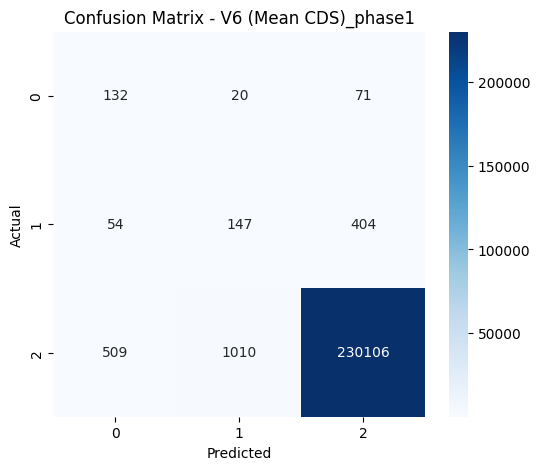

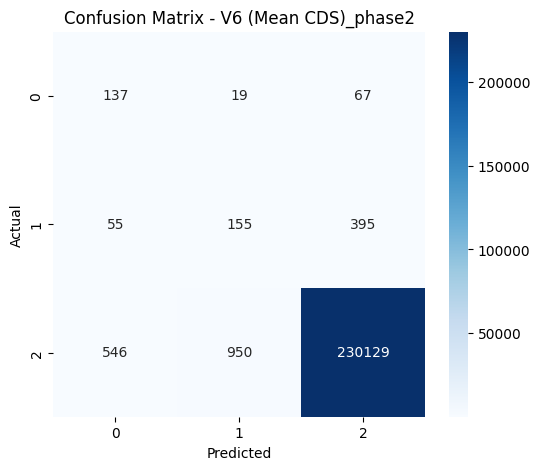

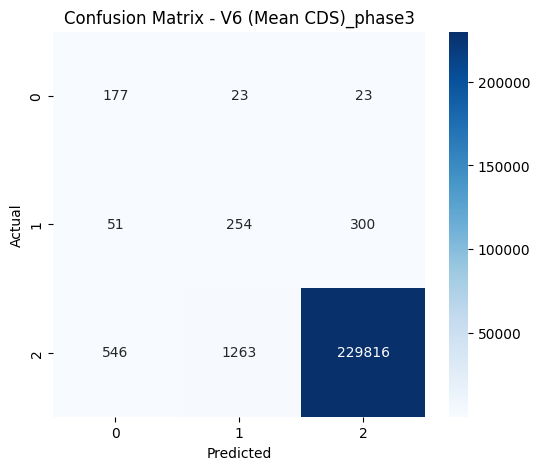

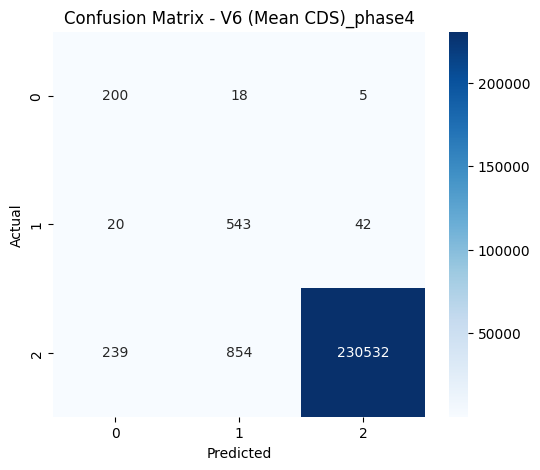

In [20]:
df_v6 = run_experiment(
    base_path=base_path,
    train_file="train_mean_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V6 (Mean CDS)"
)
df_v6

In [21]:
df_v6.to_csv("results_v6.csv", index=False)

## V7 (Mean SASMOTE)


#####
Version: V7 (Mean SAS)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0646
Epoch 2: loss = 0.0365
Epoch 3: loss = 0.0316
Epoch 4: loss = 0.0290
Epoch 5: loss = 0.0276
Epoch 6: loss = 0.0264
Epoch 7: loss = 0.0257
Epoch 8: loss = 0.0250
Epoch 9: loss = 0.0245
Epoch 10: loss = 0.0241
Epoch 11: loss = 0.0237
Epoch 12: loss = 0.0234
Epoch 13: loss = 0.0231
Epoch 14: loss = 0.0229
Epoch 15: loss = 0.0227
Epoch 16: loss = 0.0224
Epoch 17: loss = 0.0222
Epoch 18: loss = 0.0221
Epoch 19: loss = 0.0218
Epoch 20: loss = 0.0217
Epoch 21: loss = 0.0216
Epoch 22: loss = 0.0214
Epoch 23: loss = 0.0214
Epoch 24: loss = 0.0214
Epoch 25: loss = 0.0211
Epoch 26: loss = 0.0210
Epoch 27: loss = 0.0210
Epoch 28: loss = 0.0211
Epoch 29: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V7 (Mean SAS),1,3777.827588,0.019692,0.979880,0.663764,0.428084,0.995493,0.663764,0.979880,0.472740,0.987152,0.732788,0.229260,0.161743,0.217550,0.533632,0.309091,0.729828,0.068037,0.476033,0.119057,0.684056,0.998665,0.981625,0.990072,0.788176
1,V7 (Mean SAS),2,3777.827588,0.019616,0.980332,0.649220,0.424818,0.995446,0.649220,0.980332,0.467555,0.987377,0.720267,0.226841,0.161593,0.207090,0.497758,0.292490,0.704874,0.068739,0.467769,0.119864,0.678258,0.998626,0.982135,0.990312,0.781581
2,V7 (Mean SAS),3,3777.827588,0.019672,0.983076,0.796436,0.442320,0.996049,0.796436,0.983076,0.506473,0.988899,0.840981,0.306623,0.225130,0.224287,0.811659,0.351456,0.899706,0.103548,0.593388,0.176326,0.765136,0.999123,0.984259,0.991636,0.864011
3,V7 (Mean SAS),4,3777.827588,0.019645,0.994730,0.930214,0.589039,0.997644,0.930214,0.994730,0.690855,0.995818,0.955566,0.604619,0.553892,0.381404,0.901345,0.536000,0.948725,0.385877,0.894215,0.539113,0.943872,0.999835,0.995083,0.997453,0.974379


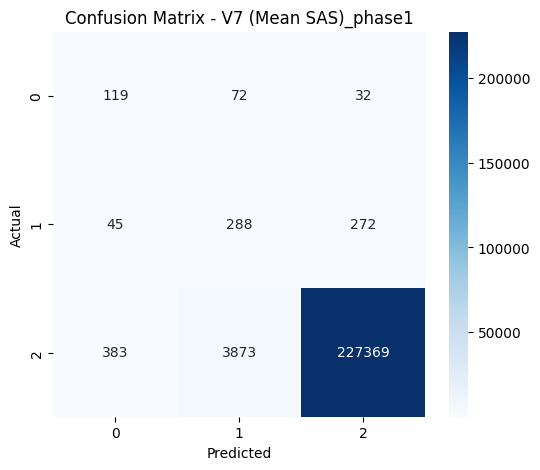

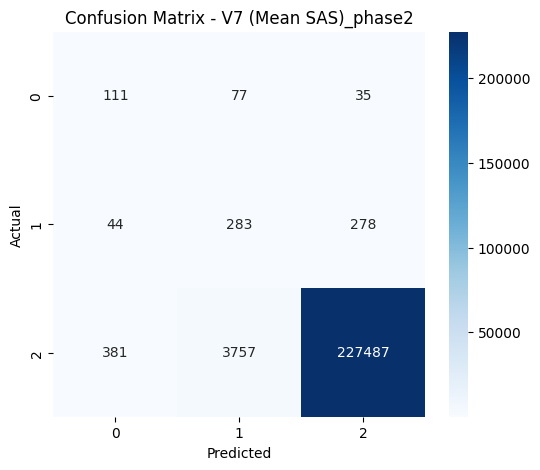

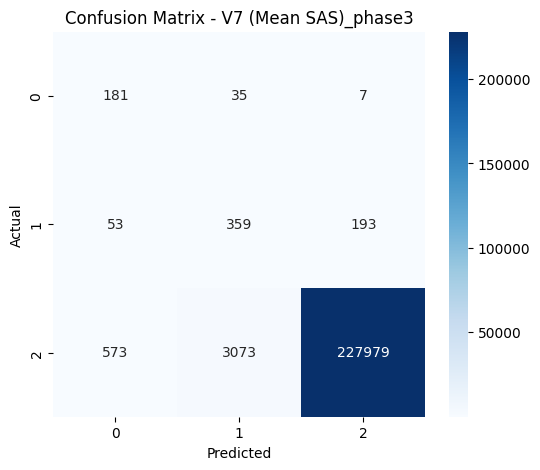

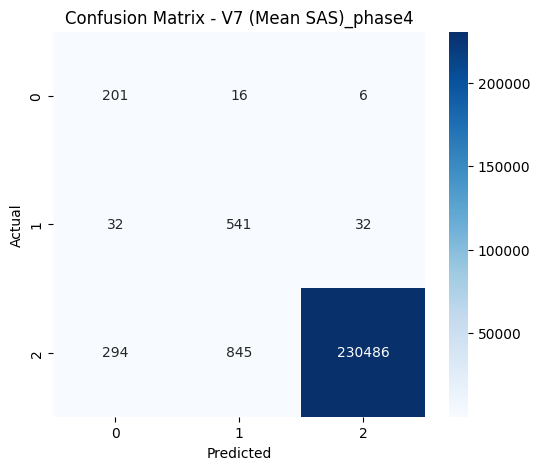

In [22]:
df_v7 = run_experiment(
    base_path=base_path,
    train_file="train_mean_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V7 (Mean SAS)"
)
df_v7

In [23]:
df_v7.to_csv("results_v7.csv", index=False)

## V8 (Mean RadiusSMOTE)


#####
Version: V8 (Mean Radius)
#####
Loading train: /kaggle/input/lo-dataset/Mean/Mean/train_mean_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0594
Epoch 2: loss = 0.0327
Epoch 3: loss = 0.0279
Epoch 4: loss = 0.0254
Epoch 5: loss = 0.0238
Epoch 6: loss = 0.0227
Epoch 7: loss = 0.0218
Epoch 8: loss = 0.0210
Epoch 9: loss = 0.0205
Epoch 10: loss = 0.0200
Epoch 11: loss = 0.0197
Epoch 12: loss = 0.0193
Epoch 13: loss = 0.0189
Epoch 14: loss = 0.0187
Epoch 15: loss = 0.0185
Epoch 16: loss = 0.0183
Epoch 17: loss = 0.0181
Epoch 18: loss = 0.0180
Epoch 19: loss = 0.0178
Epoch 20: loss = 0.0177
Epoch 21: loss = 0.0176
Epoch 22: loss = 0.0175
Epoch 23: loss = 0.0173
Epoch 24: loss = 0.0172
Epoch 25: loss = 0.0172
Epoch 26: loss = 0.0170
Epoch 27: loss = 0.0170
Epoch 28: loss = 0.0169
Epoch 29: 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V8 (Mean Radius),1,3938.88568,0.019679,0.915170,0.758249,0.359212,0.995617,0.758249,0.915170,0.367863,0.952647,0.811613,0.131460,0.049570,0.058630,0.798206,0.109236,0.887909,0.019939,0.560331,0.038507,0.721151,0.999068,0.916209,0.955846,0.834935
1,V8 (Mean Radius),2,3938.88568,0.019650,0.953156,0.767982,0.363429,0.995651,0.767982,0.953156,0.382271,0.973030,0.815948,0.177502,0.088587,0.047644,0.820628,0.090059,0.898722,0.043591,0.528926,0.080544,0.716176,0.999051,0.954392,0.976211,0.844000
2,V8 (Mean Radius),3,3938.88568,0.019877,0.940908,0.808312,0.370519,0.996018,0.808312,0.940908,0.392339,0.966567,0.861614,0.180856,0.080668,0.077720,0.807175,0.141788,0.894288,0.034425,0.676033,0.065513,0.801612,0.999414,0.941729,0.969714,0.892271
3,V8 (Mean Radius),4,3938.88568,0.019616,0.995225,0.847818,0.601640,0.997510,0.847818,0.995225,0.684811,0.996123,0.903313,0.592386,0.556576,0.439276,0.762332,0.557377,0.872708,0.365948,0.785124,0.499212,0.884498,0.999697,0.995998,0.997844,0.954880


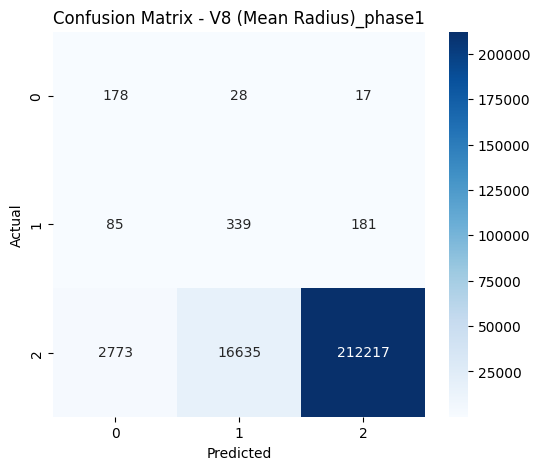

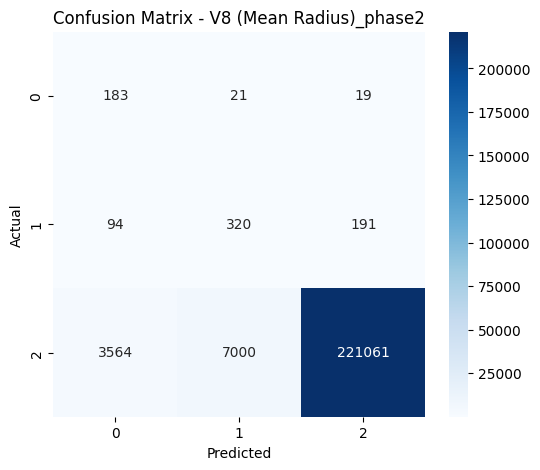

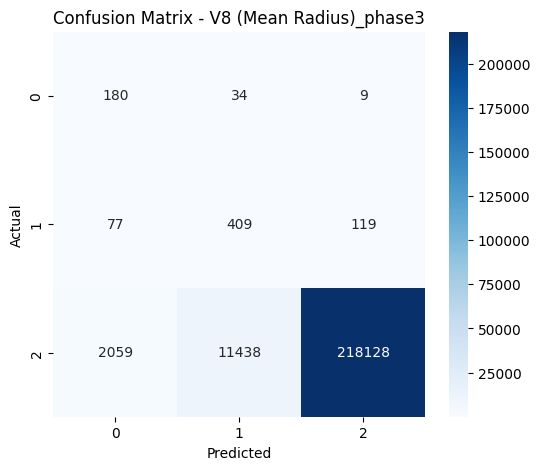

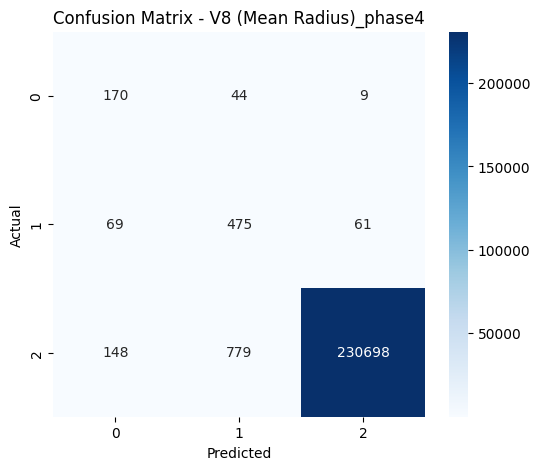

In [24]:
df_v8 = run_experiment(
    base_path=base_path,
    train_file="train_mean_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V8 (Mean Radius)"
)
df_v8

In [25]:
df_v8.to_csv("results_v8.csv", index=False)

## V9 (Extra Trees)

In [26]:
base_path = "/kaggle/input/lo-dataset/Extra_trees/Extra_trees"


#####
Version: V9 (Extra)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0095
Epoch 2: loss = 0.0064
Epoch 3: loss = 0.0058
Epoch 4: loss = 0.0055
Epoch 5: loss = 0.0052
Epoch 6: loss = 0.0050
Epoch 7: loss = 0.0049
Epoch 8: loss = 0.0048
Epoch 9: loss = 0.0047
Epoch 10: loss = 0.0046
Epoch 11: loss = 0.0045
Epoch 12: loss = 0.0045
Epoch 13: loss = 0.0045
Epoch 14: loss = 0.0043
Epoch 15: loss = 0.0043
Epoch 16: loss = 0.0042
Epoch 17: loss = 0.0042
Epoch 18: loss = 0.0042
Epoch 19: loss = 0.0041
Epoch 20: loss = 0.0042
Epoch 21: loss = 0.0041
Epoch 22: loss = 0.0041
Epoch 23: loss = 0.0041
Epoch 24: loss = 0.0041
Epoch 25: loss = 0.0040
Epoch 26: loss = 0.0040
Epoch 27: loss = 0.0040
Epoch 28: loss = 0.0039
Epoch 29: los

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V9 (Extra),1,1047.195813,0.019791,0.987770,0.432645,0.357686,0.994182,0.432645,0.987770,0.371752,0.990781,0.000000,0.152567,0.132125,0.000000,0.000000,0.000000,0.00000,0.075518,0.307438,0.121252,0.551741,0.997539,0.990498,0.994006,0.559838
1,V9 (Extra),2,1047.195813,0.019656,0.994502,0.430501,0.397469,0.994612,0.430501,0.994502,0.410613,0.994531,0.000000,0.264345,0.263980,0.000000,0.000000,0.000000,0.00000,0.194748,0.294215,0.234365,0.541554,0.997659,0.997289,0.997474,0.586919
2,V9 (Extra),3,1047.195813,0.019756,0.996567,0.564815,0.701622,0.995963,0.564815,0.996567,0.617243,0.996200,0.594748,0.427713,0.418723,0.714286,0.426009,0.533708,0.65264,0.392771,0.269421,0.319608,0.518776,0.997809,0.999016,0.998412,0.621364
3,V9 (Extra),4,1047.195813,0.019713,0.998507,0.792852,0.884150,0.998389,0.792852,0.998507,0.834262,0.998423,0.838236,0.773150,0.769453,0.853403,0.730942,0.787440,0.85490,0.800000,0.647934,0.715982,0.804773,0.999046,0.999681,0.999363,0.856071


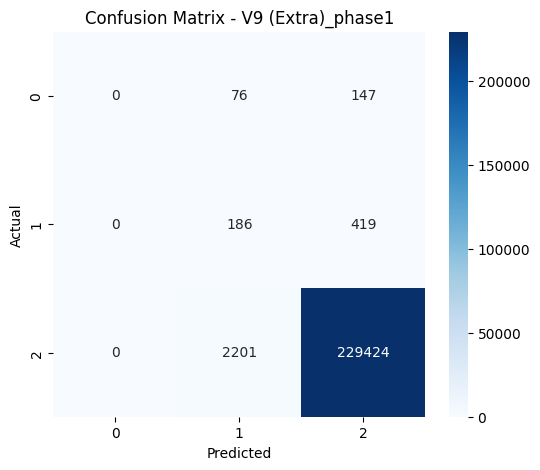

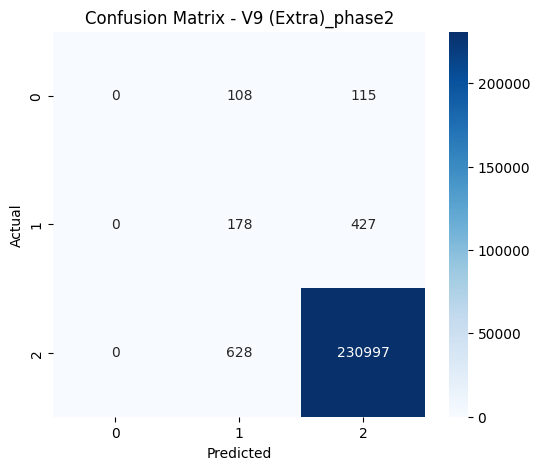

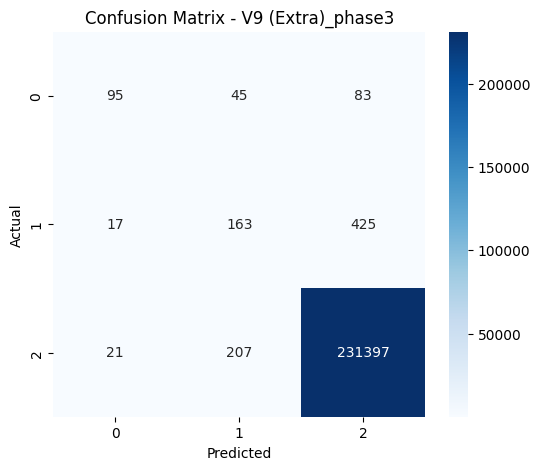

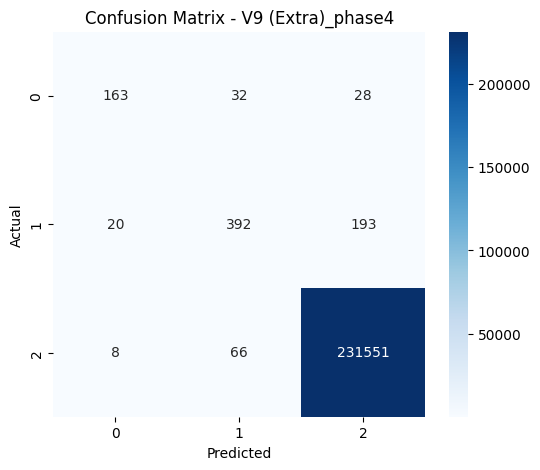

In [27]:
df_v9 = run_experiment(
    base_path=base_path,
    train_file="train_extra.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V9 (Extra)"
)
df_v9

In [28]:
df_v9.to_csv("results_v9.csv", index=False)

## V10 (Extra Trees CDSMOTE)


#####
Version: V10 (Extra CDS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_cdsmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0584
Epoch 2: loss = 0.0286
Epoch 3: loss = 0.0240
Epoch 4: loss = 0.0219
Epoch 5: loss = 0.0205
Epoch 6: loss = 0.0195
Epoch 7: loss = 0.0188
Epoch 8: loss = 0.0182
Epoch 9: loss = 0.0178
Epoch 10: loss = 0.0173
Epoch 11: loss = 0.0170
Epoch 12: loss = 0.0168
Epoch 13: loss = 0.0165
Epoch 14: loss = 0.0162
Epoch 15: loss = 0.0161
Epoch 16: loss = 0.0157
Epoch 17: loss = 0.0156
Epoch 18: loss = 0.0154
Epoch 19: loss = 0.0154
Epoch 20: loss = 0.0152
Epoch 21: loss = 0.0152
Epoch 22: loss = 0.0149
Epoch 23: loss = 0.0149
Epoch 24: loss = 0.0148
Epoch 25: loss = 0.0148
Epoch 26: loss = 0.0147
Epoch 27: loss = 0.0146
Epoch 28: loss = 0.0145


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V10 (Extra CDS),1,3864.674563,0.020267,0.990940,0.412908,0.403231,0.994096,0.412908,0.990940,0.382247,0.992387,0.302164,0.146371,0.138303,0.125000,0.013453,0.024291,0.115981,0.087391,0.231405,0.126869,0.479527,0.997301,0.993865,0.995580,0.496050
1,V10 (Extra CDS),2,3864.674563,0.020308,0.991891,0.404744,0.376394,0.993976,0.404744,0.991891,0.378983,0.992861,0.245689,0.147354,0.142615,0.035714,0.004484,0.007968,0.066961,0.096225,0.214876,0.132924,0.462325,0.997243,0.994871,0.996056,0.479054
2,V10 (Extra CDS),3,3864.674563,0.019849,0.989378,0.700990,0.462493,0.995526,0.700990,0.989378,0.523432,0.992142,0.742514,0.305282,0.262622,0.253356,0.677130,0.368742,0.822090,0.135637,0.434711,0.206761,0.656939,0.998486,0.991128,0.994794,0.758002
3,V10 (Extra CDS),4,3864.674563,0.019916,0.995707,0.901093,0.616394,0.997643,0.901093,0.995707,0.710457,0.996435,0.931926,0.624154,0.590448,0.410042,0.878924,0.559201,0.936940,0.439474,0.828099,0.574212,0.908745,0.999666,0.996257,0.997959,0.950584


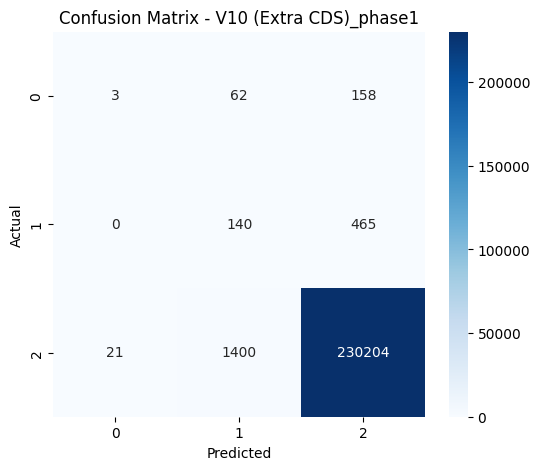

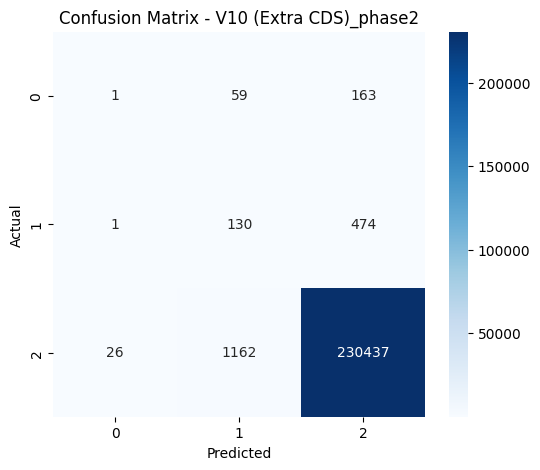

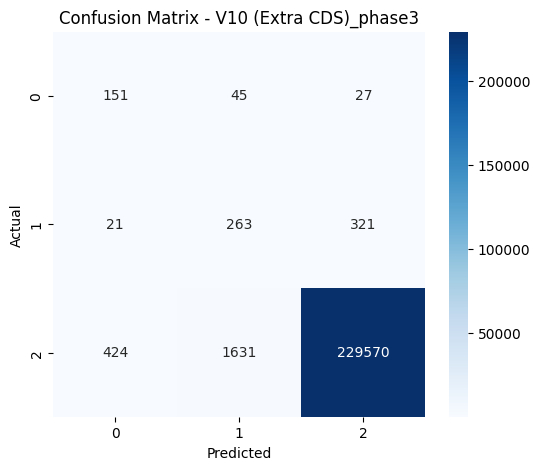

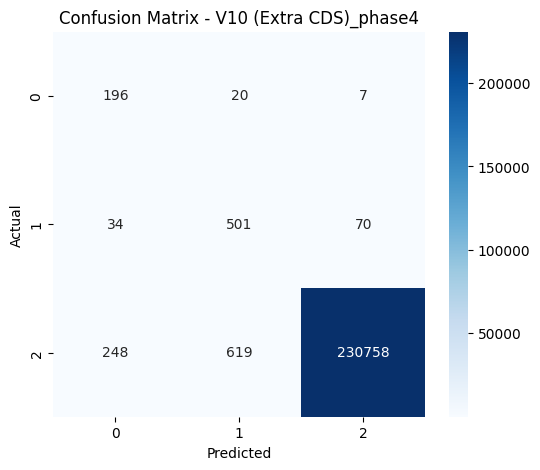

In [29]:
df_v10 = run_experiment(
    base_path=base_path,
    train_file="train_extra_cdsmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V10 (Extra CDS)"
)
df_v10

In [30]:
df_v10.to_csv("results_v10.csv", index=False)

## V11 (Extra Trees SASMOTE)


#####
Version: V11 (Extra SAS)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_sasmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0592
Epoch 2: loss = 0.0289
Epoch 3: loss = 0.0242
Epoch 4: loss = 0.0220
Epoch 5: loss = 0.0206
Epoch 6: loss = 0.0195
Epoch 7: loss = 0.0188
Epoch 8: loss = 0.0183
Epoch 9: loss = 0.0179
Epoch 10: loss = 0.0175
Epoch 11: loss = 0.0171
Epoch 12: loss = 0.0169
Epoch 13: loss = 0.0166
Epoch 14: loss = 0.0164
Epoch 15: loss = 0.0161
Epoch 16: loss = 0.0160
Epoch 17: loss = 0.0158
Epoch 18: loss = 0.0157
Epoch 19: loss = 0.0156
Epoch 20: loss = 0.0155
Epoch 21: loss = 0.0154
Epoch 22: loss = 0.0152
Epoch 23: loss = 0.0151
Epoch 24: loss = 0.0151
Epoch 25: loss = 0.0149
Epoch 26: loss = 0.0149
Epoch 27: loss = 0.0149
Epoch 28: loss = 0.0147


,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V11 (Extra SAS),1,4139.029885,0.019668,0.995173,0.374783,0.412982,0.993604,0.374783,0.995173,0.387715,0.994355,0.264364,0.102140,0.096352,0.140496,0.076233,0.098837,0.276042,0.101695,0.049587,0.066667,0.222554,0.996755,0.998528,0.997641,0.300743
1,V11 (Extra SAS),2,4139.029885,0.019787,0.995358,0.371845,0.427376,0.993785,0.371845,0.995358,0.386121,0.994518,0.261794,0.127670,0.119634,0.142857,0.035874,0.057348,0.189386,0.142442,0.080992,0.103267,0.284409,0.996828,0.998670,0.997748,0.333112
2,V11 (Extra SAS),3,4139.029885,0.019724,0.994373,0.631772,0.512873,0.995153,0.631772,0.994373,0.552390,0.994705,0.624270,0.320444,0.317330,0.330416,0.677130,0.444118,0.822337,0.210361,0.221488,0.215781,0.470114,0.997843,0.996697,0.997270,0.629310
3,V11 (Extra SAS),4,4139.029885,0.019950,0.996253,0.888314,0.637928,0.997721,0.888314,0.996253,0.725957,0.996807,0.922723,0.644312,0.618766,0.436073,0.856502,0.577912,0.924982,0.478092,0.811570,0.601716,0.899830,0.999619,0.996870,0.998243,0.943887


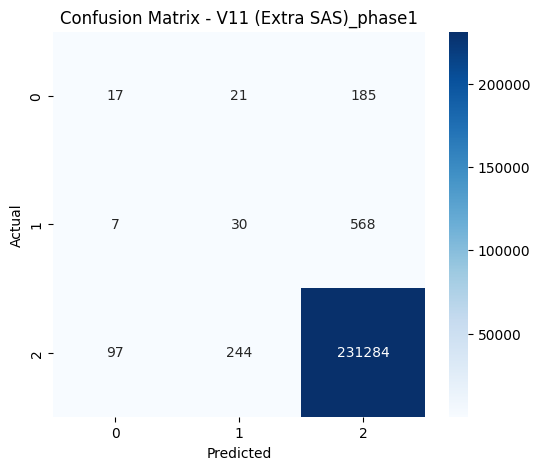

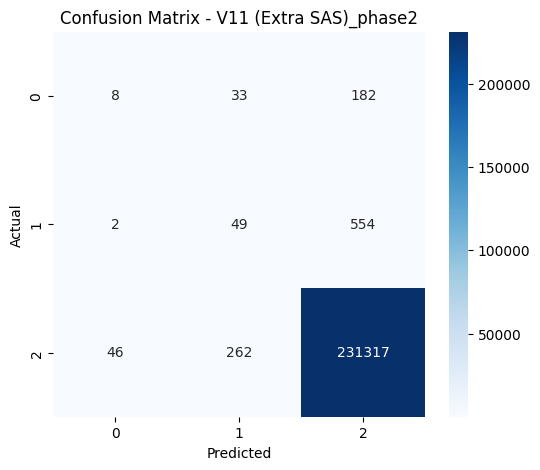

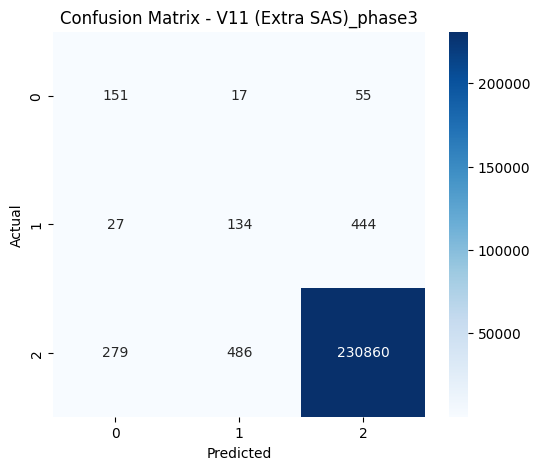

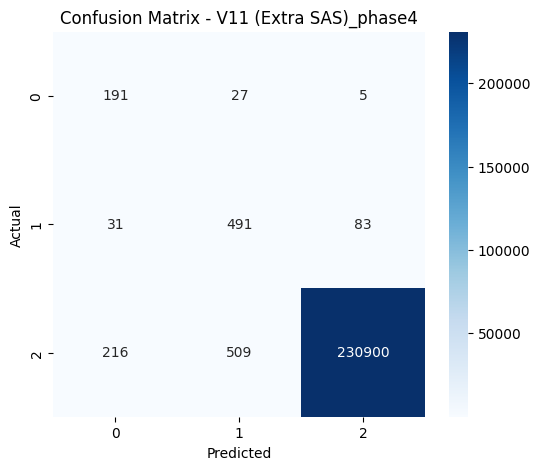

In [31]:
df_v11 = run_experiment(
    base_path=base_path,
    train_file="train_extra_sasmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V11 (Extra SAS)"
)
df_v11

In [32]:
df_v11.to_csv("results_v11.csv", index=False)

## V12 (Extra Trees RadiusSMOTE)


#####
Version: V12 (Extra Radius)
#####
Loading train: /kaggle/input/lo-dataset/Extra_trees/Extra_trees/train_extra_radiussmote.csv
Combined train + val: 5791443 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (5791443, 4, 39)
Static feature shape: (5791443, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0479
Epoch 2: loss = 0.0207
Epoch 3: loss = 0.0172
Epoch 4: loss = 0.0155
Epoch 5: loss = 0.0145
Epoch 6: loss = 0.0139
Epoch 7: loss = 0.0134
Epoch 8: loss = 0.0131
Epoch 9: loss = 0.0127
Epoch 10: loss = 0.0126
Epoch 11: loss = 0.0122
Epoch 12: loss = 0.0121
Epoch 13: loss = 0.0119
Epoch 14: loss = 0.0119
Epoch 15: loss = 0.0117
Epoch 16: loss = 0.0116
Epoch 17: loss = 0.0116
Epoch 18: loss = 0.0115
Epoch 19: loss = 0.0113
Epoch 20: loss = 0.0114
Epoch 21: loss = 0.0112
Epoch 22: loss = 0.0111
Epoch 23: loss = 0.0112
Epoch 24: loss = 0.0111
Epoch 25: loss = 0.0111
Epoch 26: loss = 0.0110
Epoch 27: loss = 0.0110
Epoch 28: loss = 

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,V12 (Extra Radius),1,4199.296667,0.020321,0.993353,0.480617,0.485387,0.994889,0.480617,0.993353,0.454095,0.993982,0.482969,0.201485,0.199278,0.070284,0.255605,0.110251,0.504753,0.388514,0.190083,0.255272,0.435814,0.997363,0.996162,0.996762,0.512127
1,V12 (Extra Radius),2,4199.296667,0.020357,0.994567,0.487533,0.492868,0.994917,0.487533,0.994567,0.476082,0.994672,0.494754,0.245381,0.245320,0.111340,0.242152,0.152542,0.491633,0.369863,0.223140,0.278351,0.472143,0.997401,0.997306,0.997353,0.521739
2,V12 (Extra Radius),3,4199.296667,0.020375,0.995909,0.648005,0.607973,0.996160,0.648005,0.995909,0.626482,0.996029,0.697202,0.457218,0.456485,0.439850,0.524664,0.478528,0.724104,0.385779,0.421488,0.402844,0.648652,0.998290,0.997863,0.998076,0.721543
3,V12 (Extra Radius),4,4199.296667,0.020329,0.996485,0.815734,0.634877,0.997503,0.815734,0.996485,0.703062,0.996899,0.869615,0.622363,0.608503,0.413366,0.748879,0.532695,0.864936,0.491879,0.700826,0.578050,0.836363,0.999386,0.997496,0.998440,0.909081


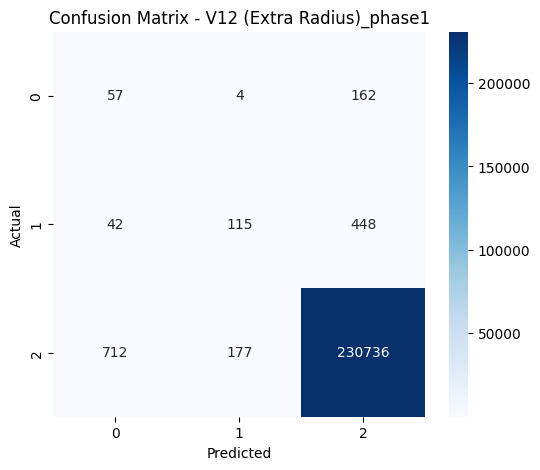

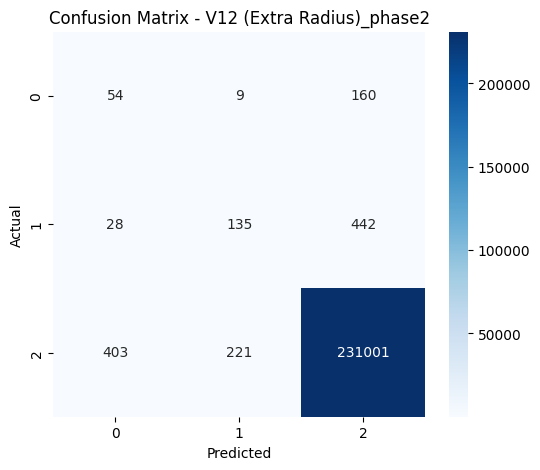

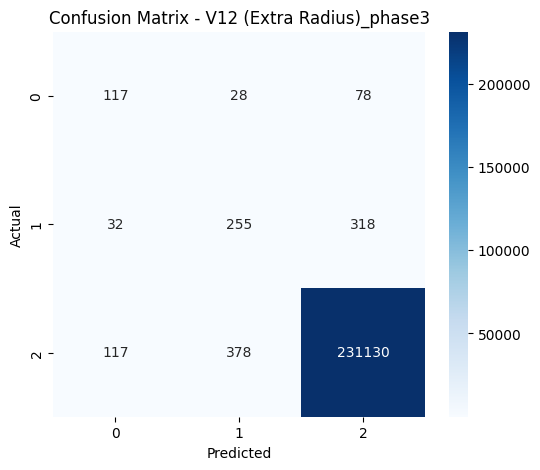

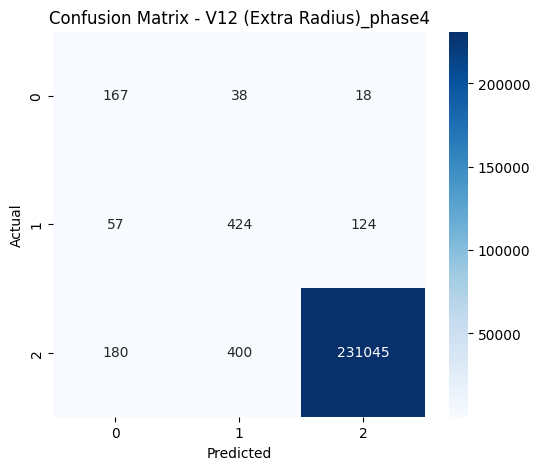

In [33]:
df_v12 = run_experiment(
    base_path=base_path,
    train_file="train_extra_radiussmote.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="V12 (Extra Radius)"
)
df_v12

In [34]:
df_v12.to_csv("results_v12.csv", index=False)